<a href="https://colab.research.google.com/github/aditya-03-githere/deep-learning-practice/blob/main/RNN/RNN_Movie_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input

In [3]:
# load the imdb dataset
max_features=10000
(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=max_features)

print(f'Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}')

Training data shape: (25000,), Training labels shape: (25000,)
Testing data shape: (25000,), Testing labels shape: (25000,)


In [4]:
# inspect a sample review and its label
sample_review = X_train[0]
sample_label = y_train[0]
print(f'Sample review: {sample_review}')
print(f'Sample label: {sample_label}')

Sample review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample label: 1


In [5]:
max_len = 500
X_train = sequence.pad_sequences(X_train,maxlen=max_len)
X_test = sequence.pad_sequences(X_test,maxlen=max_len)

In [6]:
X_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [7]:
# RNN model
model = Sequential([
    Embedding(max_features,output_dim=128,input_length=max_len),
    SimpleRNN(128, activation='tanh'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.predict(X_train)
model.summary()

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 500, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (32, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [12]:
history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 218ms/step - accuracy: 0.5563 - loss: 0.6773 - val_accuracy: 0.6102 - val_loss: 0.6481
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 221ms/step - accuracy: 0.7138 - loss: 0.5545 - val_accuracy: 0.7944 - val_loss: 0.4680
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 221ms/step - accuracy: 0.8070 - loss: 0.4206 - val_accuracy: 0.7170 - val_loss: 0.5896
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 226ms/step - accuracy: 0.8260 - loss: 0.3872 - val_accuracy: 0.7618 - val_loss: 0.5372
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 219ms/step - accuracy: 0.8621 - loss: 0.3295 - val_accuracy: 0.6698 - val_loss: 0.6574
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 220ms/step - accuracy: 0.8863 - loss: 0.2830 - val_accuracy: 0.7758 - val_loss: 0.5478
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 223ms/step - accuracy: 0.9269 - loss: 0.1973 - val_accuracy: 0.7508 - val_loss: 0.6466


In [13]:
model.get_weights()

[array([[-0.02832447,  0.01220692, -0.0188782 , ..., -0.0432743 ,
          0.03339041,  0.00726155],
        [-0.01901709, -0.0631263 , -0.00074778, ...,  0.04027452,
          0.01856525,  0.01823446],
        [ 0.01549131, -0.0171347 , -0.04537779, ...,  0.06173944,
          0.0058171 , -0.00227653],
        ...,
        [ 0.01023154,  0.06013933, -0.05108873, ..., -0.01546679,
          0.05823192,  0.03860652],
        [-0.0463439 , -0.02693706, -0.03577036, ..., -0.02221398,
          0.02972652,  0.02526421],
        [-0.03588988,  0.02001419,  0.06778863, ...,  0.01469827,
         -0.01354751,  0.01576585]], dtype=float32),
 array([[-0.01521949, -0.01156212,  0.06934233, ...,  0.04081212,
         -0.16273324,  0.02188013],
        [-0.1748424 , -0.01852126,  0.08299134, ...,  0.03859539,
         -0.02839494,  0.06004329],
        [ 0.06309794, -0.10955491, -0.01658595, ...,  0.20310095,
         -0.04334546,  0.09261352],
        ...,
        [ 0.12129427, -0.06507667,  0.1

In [17]:
# Get the word index mappings (needed to decode/encode reviews)
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

# Function to decode reviews
def decode_review(encoded_review):
  return ' '.join([reverse_word_index.get(i-3,'?') for i in encoded_review])

def preprocess_text(text):
  words = text.lower().split()
  encoded_review = [word_index.get(word,2)+3 for word in words]
  padded_review = sequence.pad_sequences([encoded_review],maxlen=500)
  return padded_review


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
def predict_sentiment(review):
  preprocessed_input = preprocess_text(review)

  prediction = model.predict(preprocessed_input)
  sentiment = 'Positive' if prediction[0][0] > 0.5 else 'Negative'

  return sentiment, prediction[0][0]

In [22]:
example_review = "This movie was great and I loved it!"
sentiment,score = predict_sentiment(example_review)

print(f'Review: {example_review}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Review: This movie was great and I loved it!
Sentiment: Positive
Prediction Score: 0.5908097624778748


In [24]:
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)

782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step


In [31]:
y_pred_prob = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step


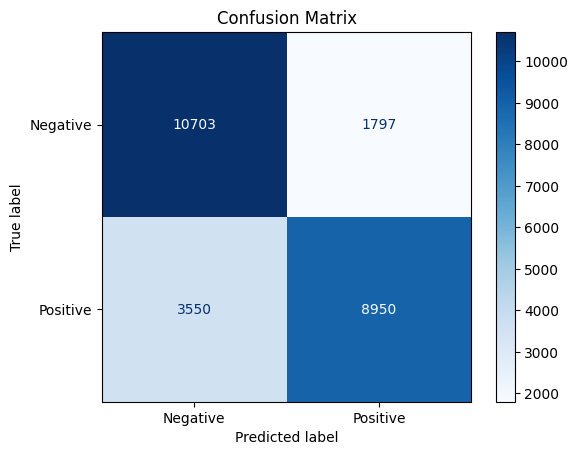

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

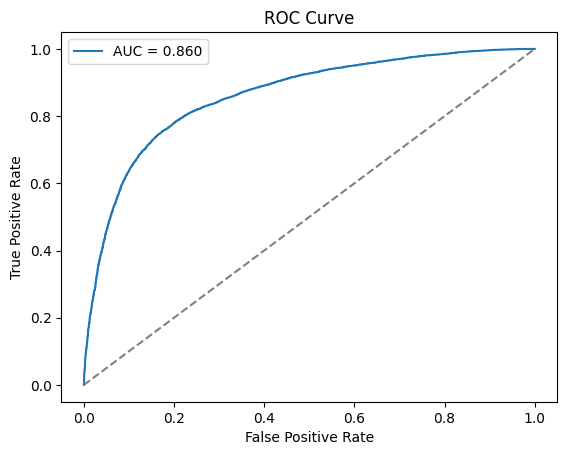

In [33]:
from sklearn.metrics import roc_auc_score, roc_curve

# y_pred_prob = raw sigmoid outputs (shape (25000, 1))
auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.title('ROC Curve')
plt.show()

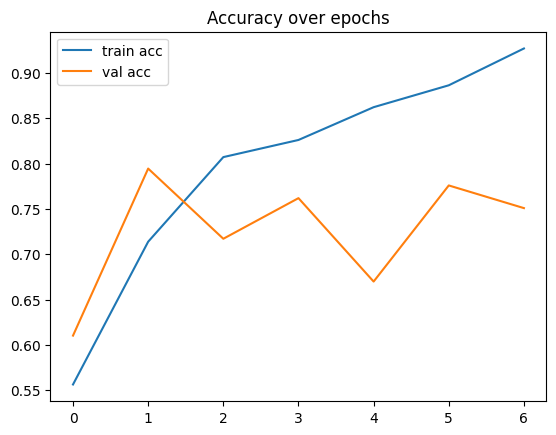

In [28]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('Accuracy over epochs')
plt.show()